In [1]:
import pandas as pd
import numpy as np
from metrics.similarity import WeightedUserSimilarity
import matplotlib.pyplot as plt

In [2]:
TRAIN_PATH = '../data/train.csv'

train_data = pd.read_csv(TRAIN_PATH)

train_data

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0
...,...,...,...
390346,77801,185970,5.0
390347,77801,185971,5.0
390348,77802,44671,10.0
390349,77803,154450,10.0


     n_appearances   count
0                1  120474
1                2   23790
2                3    9127
3                4    4778
4                5    2969
..             ...     ...
175            157       1
176            158       1
177            161       1
178            164       1
179            707       1

[180 rows x 2 columns]


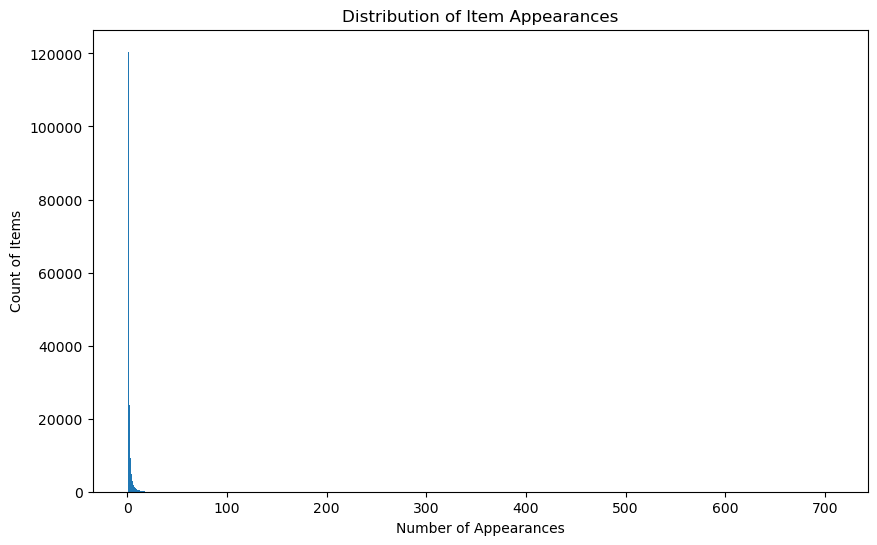

In [3]:
# Count the times each item appears in the dataset
item_counts = train_data['item'].value_counts()

n_appearances = item_counts.value_counts()

n_appearances = n_appearances.rename_axis('n_appearances').reset_index(name='count')

print(n_appearances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(n_appearances['n_appearances'], n_appearances['count'])
ax.set_xlabel('Number of Appearances')
ax.set_ylabel('Count of Items')
ax.set_title('Distribution of Item Appearances')
plt.show()

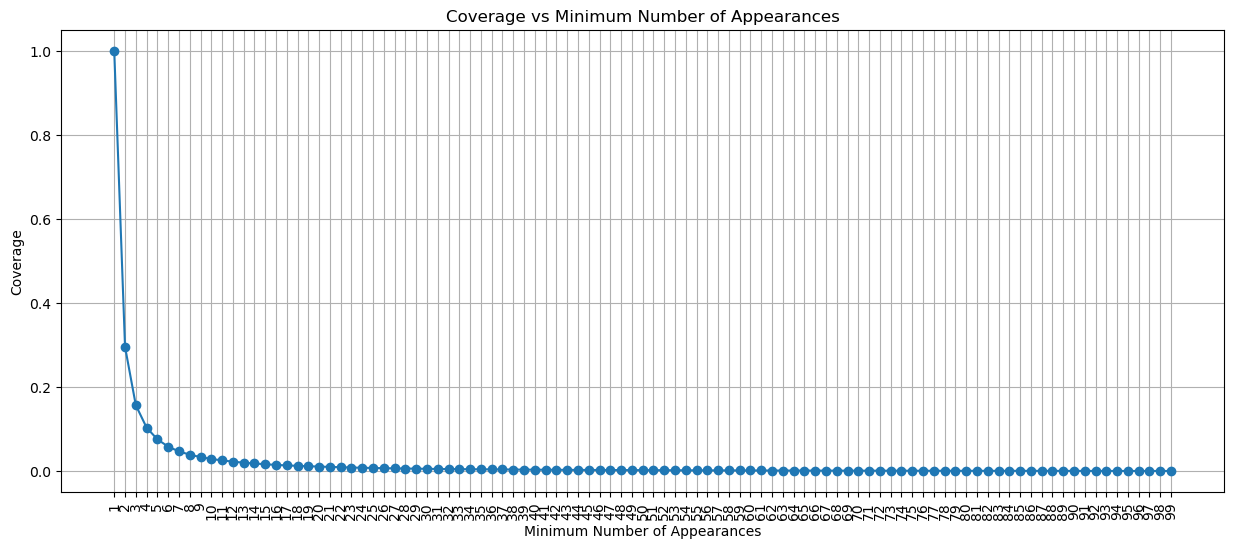

In [4]:
# I want to see the coverage if i only recommend items that appear at least n times
# I will calculate the coverage for different values of n and plot it

total_items = len(item_counts)
coverage = []

for n in range(1, 100):
    items_to_recommend = item_counts[item_counts >= n].index
    coverage.append(len(items_to_recommend) / total_items)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(range(1, 100), coverage, marker='o')
ax.set_xlabel('Minimum Number of Appearances')
ax.set_ylabel('Coverage')
ax.set_title('Coverage vs Minimum Number of Appearances')
plt.xticks(range(1, 100), rotation=90)
plt.grid()
plt.show()

In [ ]:
from model.PMF import MatrixFactorization
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(train_data, test_size=0.2, random_state=42)

mf = MatrixFactorization(n_factors=10, n_epochs=80, lr=0.1, reg=0.5, verbose=True)
mf = mf.fit(train_data)

predictions = mf.predict_df(test_data)

predictions

Epoch 001/80 - RMSE train: 1.7044
Epoch 002/80 - RMSE train: 1.4872
Epoch 003/80 - RMSE train: 1.3731
Epoch 004/80 - RMSE train: 1.2924
Epoch 005/80 - RMSE train: 1.2273
Epoch 006/80 - RMSE train: 1.1736
Epoch 007/80 - RMSE train: 1.1268
Epoch 008/80 - RMSE train: 1.0870
Epoch 009/80 - RMSE train: 1.0529
Epoch 010/80 - RMSE train: 1.0246
Epoch 011/80 - RMSE train: 0.9988
Epoch 012/80 - RMSE train: 0.9781
Epoch 013/80 - RMSE train: 0.9595
Epoch 014/80 - RMSE train: 0.9434
Epoch 015/80 - RMSE train: 0.9297
Epoch 016/80 - RMSE train: 0.9187
Epoch 017/80 - RMSE train: 0.9083
Epoch 018/80 - RMSE train: 0.8993
Epoch 019/80 - RMSE train: 0.8915
Epoch 020/80 - RMSE train: 0.8847
Epoch 021/80 - RMSE train: 0.8782
Epoch 022/80 - RMSE train: 0.8730
Epoch 023/80 - RMSE train: 0.8680
Epoch 024/80 - RMSE train: 0.8647
Epoch 025/80 - RMSE train: 0.8599
Epoch 026/80 - RMSE train: 0.8569
Epoch 027/80 - RMSE train: 0.8544
Epoch 028/80 - RMSE train: 0.8514
Epoch 029/80 - RMSE train: 0.8483
Epoch 030/80 -

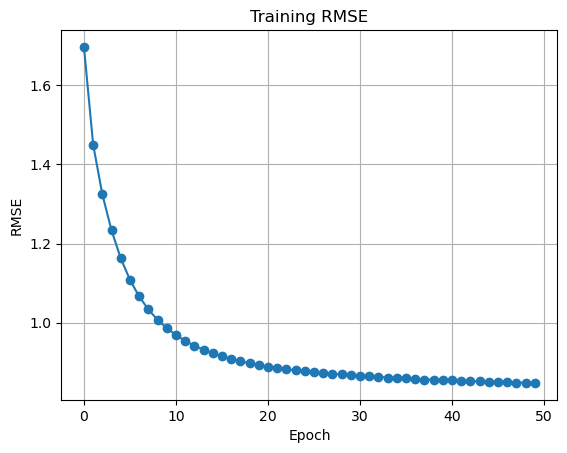

In [6]:
mf.plot_training()

Mean Absolute Error: 1.3351


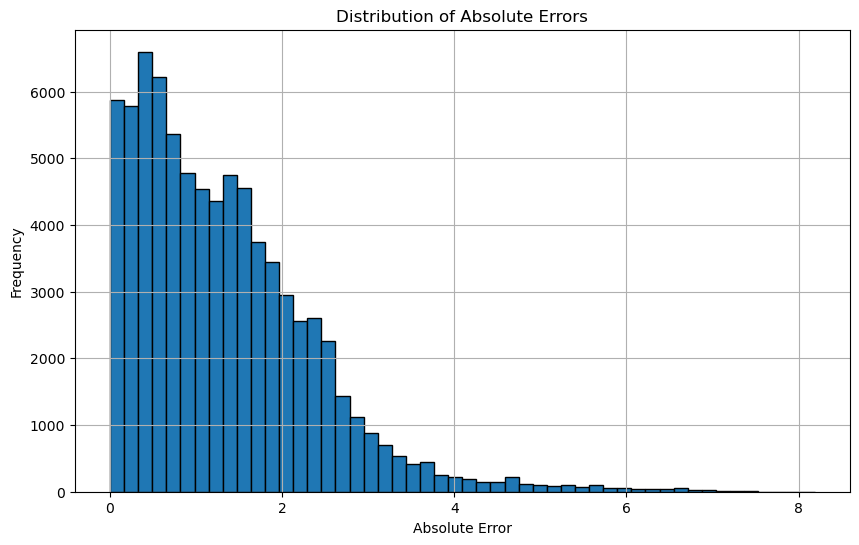

In [8]:
errors = np.abs(predictions['rating'] - predictions['prediction'])

print(f'Mean Absolute Error: {errors.mean():.4f}')
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.grid()